# Baseline Model — Click Prediction with Top-K Ranking Metrics

A simple logistic regression baseline for predicting `click`, trained on
`output/train.csv` and evaluated on the time-held-out `output/test.csv`
produced by `Sample_Dataset.ipynb`.

`Sample_Dataset.ipynb` restricts the ad catalog to the **top 300
most-frequent products**, so `adgroup_id` itself is a low-cardinality,
learnable feature (each product has thousands of impressions instead of
being a near-unique ID).

Evaluation treats every real click in the test period as one query
("this user showed up — which of the 300 products would they see first?"):
score all 300 catalog products for that context, rank them, and check
where the actually-clicked product landed. This is closer to what a real
user experiences than pooling every impression into one global ranking.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42

train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train['click'].mean():.4%}  |  test CTR: {test['click'].mean():.4%}")

train: (240000, 21) test: (60000, 21)
train CTR: 20.1858%  |  test CTR: 19.2567%


## Features

- **Numeric:** `price` (the ad's item price)
- **Categorical (one-hot):** the product itself (`adgroup_id` — only 300
  unique values now, so its own historical CTR becomes directly learnable),
  ad category (`cate_id`), user demographics (`cms_group_id`,
  `final_gender_code`, `age_level`, `pvalue_level`, `shopping_level`,
  `occupation`, `new_user_class_level`), ad slot (`pid`), and time-of-week
  (`hour`, `weekday`)

`campaign_id`, `customer`, and `brand` are still left out — they're
near-unique IDs (tens of thousands of categories) that a simple one-hot
logistic regression would just memorize rather than generalize from;
they're natural candidates for a follow-up model (e.g. target/frequency
encoding or a tree-based model).

In [2]:
NUMERIC_FEATURES = ["price"]
CATEGORICAL_FEATURES = [
    "adgroup_id", "cate_id", "cms_group_id", "final_gender_code", "age_level",
    "pvalue_level", "shopping_level", "occupation", "new_user_class_level",
    "pid", "hour", "weekday",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "click"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['price','adgroup_id','cate_id',...,'pid','hour','weekday']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

## Standard classification sanity checks

CTR is heavily imbalanced (~5% positive), so accuracy at a 0.5 threshold
isn't informative — AUC and log loss are the right sanity checks before
looking at the ranking metric we actually care about.

In [3]:
y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
ll = log_loss(y_test, y_score)
print(f"AUC:      {auc:.4f}  (0.5 = random)")
print(f"Log loss: {ll:.4f}  (lower is better)")

AUC:      0.5759  (0.5 = random)
Log loss: 0.4856  (lower is better)


## Evaluation

Treat every real click in the test period as one query: score all 300
catalog products for that user's context, rank them, and check where the
actually-clicked product landed.

- **Precision@K**:
  - *Trong K sản phẩm model recommend, có đúng sản phẩm user đã click không?*
  - Pool every query's top-K slots together: (số slot đúng) / (tổng số slot)
- **Recall@K**:
  - Mỗi query chỉ có đúng 1 sản phẩm liên quan, nên Recall@K ở đây chính là
    HitRate@K: *tỷ lệ query mà sản phẩm đã click nằm trong top K*.
- **Random baseline**: with 300 products, a random top-K list contains the
  true product with probability `K / 300`.

Note: if a user clicked 2 different products in the test period, that's 2
separate queries here (simpler code — the trade-off is that user gets
counted twice instead of once).

Ex: 100 query, top-10 mỗi query.
- Recall@10 (= HitRate@10): 60 trong 100 query có sản phẩm đã click nằm trong top 10 => 60/100 = 60%
- Precision@10: gộp top-10 của cả 100 query lại (1000 slot), trong đó 60 slot là đúng sản phẩm đã click => 60/1000 = 6%

In [4]:
PRODUCT_FEATURES = ["adgroup_id", "cate_id", "price"]
USER_FEATURES = [
    "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]
K_VALUES = [10, 50, 100]

# The catalog: one row per product, with its (constant) product-level features
catalog = (
    pd.concat([train[PRODUCT_FEATURES], test[PRODUCT_FEATURES]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)
n_catalog = len(catalog)
print(f"Product catalog: {n_catalog} unique products")

Product catalog: 300 unique products


In [5]:
# One query per real click in the test period. A user who clicked twice
# becomes two separate queries here (simpler code than tracking per-user sets).
queries = test[test["click"] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)
print(f"Evaluating {n_queries} clicks")

Evaluating 11554 clicks


In [6]:
# Cross join: every click paired with every catalog product, so we can score
# "if this user showed up right now, how would each of the 300 products rank?"
cross = queries[["query_id", "adgroup_id"] + USER_FEATURES].rename(
    columns={"adgroup_id": "true_adgroup_id"}
).merge(catalog, how="cross")

cross["score"] = model.predict_proba(cross[FEATURES])[:, 1]
cross["rank"] = cross.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1

In [7]:
# Where did the actually-clicked product land in the ranking?
true_product_rank = (
    cross.loc[cross["adgroup_id"] == cross["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)

In [8]:
rows = []
for k in K_VALUES:
    hit = true_product_rank < k

    recall_at_k = hit.mean()                    # exactly 1 relevant product per query
    precision_at_k = hit.sum() / (n_queries * k)  # pool every query's K slots together

    random_precision = 1 / n_catalog
    random_recall = k / n_catalog

    rows.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Random Precision@K": random_precision,
        "Random Recall@K": random_recall,
        "Precision lift": precision_at_k / random_precision,
    })

user_results = pd.DataFrame(rows).set_index("K")
user_results

,Precision@K,Recall@K,Random Precision@K,Random Recall@K,Precision lift
K,,,,,
10,0.010646,0.106457,0.003333,0.033333,3.193699
50,0.006877,0.343864,0.003333,0.166667,2.063182
100,0.005391,0.539121,0.003333,0.333333,1.617362


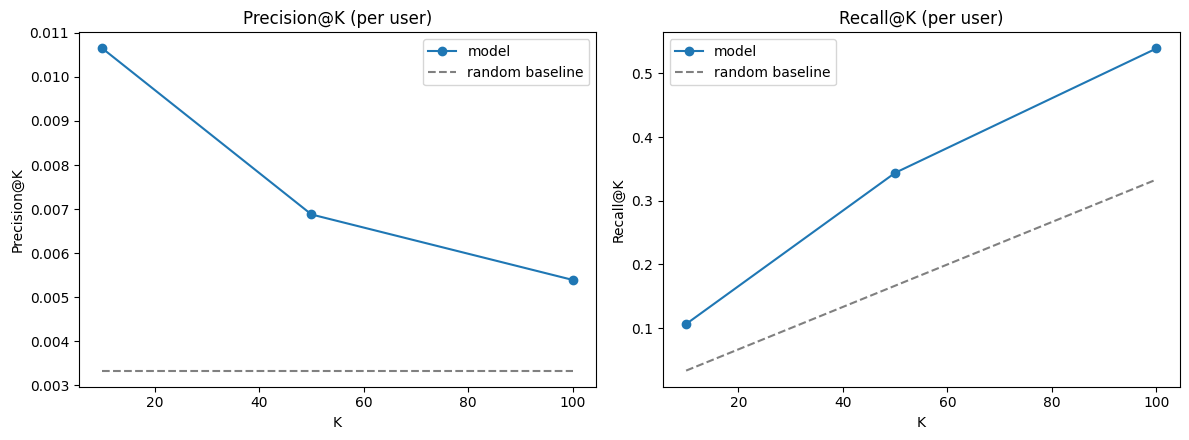

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(user_results.index, user_results["Precision@K"], marker="o", label="model")
axes[0].plot(user_results.index, user_results["Random Precision@K"], color="gray", linestyle="--", label="random baseline")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (per user)")
axes[0].legend()

axes[1].plot(user_results.index, user_results["Recall@K"], marker="o", label="model")
axes[1].plot(user_results.index, user_results["Random Recall@K"], color="gray", linestyle="--", label="random baseline")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K (per user)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Add Features

1. **GAUC** — same model, new metric: AUC computed per user, weighted by
   that user's impression count, then averaged. Answers "does the model
   rank ads well *within* a user's own options?" rather than just across
   the whole population.
2. **+ campaign_id / customer / brand** — same evaluation, retrain the
   model with the three features the baseline explicitly left out.

In [ ]:
USER_ID_COL = next((c for c in ["userid", "user_id", "user"] if c in test.columns), None)
assert USER_ID_COL is not None, (
    "No user id column found in test.columns — check the actual column name "
    "and set USER_ID_COL manually."
)
print("Using user id column:", USER_ID_COL)
print("Unique users in test:", test[USER_ID_COL].nunique())

Using user id column: userid
Unique users in test: 47608


In [ ]:
def gauc(y_true, y_score, group_ids):
    df = pd.DataFrame({"y_true": y_true, "y_score": y_score, "group": group_ids})
    weighted_sum, weight_total, skipped = 0.0, 0, 0
    for _, g in df.groupby("group"):
        if g["y_true"].nunique() < 2:
            skipped += len(g)
            continue
        weighted_sum += roc_auc_score(g["y_true"], g["y_score"]) * len(g)
        weight_total += len(g)
    return weighted_sum / weight_total, skipped, weight_total

gauc_score, gauc_skipped, gauc_weight = gauc(y_test, y_score, test[USER_ID_COL])
print(f"AUC:  {auc:.4f}")
print(f"GAUC: {gauc_score:.4f}  (skipped {gauc_skipped}/{len(test)} single-class-group rows)")

AUC:  0.5759
GAUC: 0.5543  (skipped 52976/60000 single-class-group rows)


### Exp: add `campaign_id`, `customer`, `brand`

These are near-unique IDs the baseline left out. Retrain the same
LogisticRegression pipeline with them added, then compare AUC and re-run
the top-K ranking eval so it's a fair side-by-side with the baseline row
in `experiments.md`.

In [12]:
EXTRA_FEATURES = [c for c in ["campaign_id", "customer", "brand"] if c in train.columns]
print("Extra features found in train.columns:", EXTRA_FEATURES)

CATEGORICAL_FEATURES_V2 = CATEGORICAL_FEATURES + EXTRA_FEATURES
FEATURES_V2 = NUMERIC_FEATURES + CATEGORICAL_FEATURES_V2

X_train_v2, X_test_v2 = train[FEATURES_V2], test[FEATURES_V2]

preprocess_v2 = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES_V2),
])

model_v2 = Pipeline([
    ("preprocess", preprocess_v2),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

model_v2.fit(X_train_v2, y_train)

y_score_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
auc_v2 = roc_auc_score(y_test, y_score_v2)
gauc_v2, _, _ = gauc(y_test, y_score_v2, test[USER_ID_COL])

print(f"AUC   baseline -> +features: {auc:.4f} -> {auc_v2:.4f}")
print(f"GAUC  baseline -> +features: {gauc_score:.4f} -> {gauc_v2:.4f}")

Extra features found in train.columns: ['campaign_id', 'customer', 'brand']


AUC   baseline -> +features: 0.5759 -> 0.5755
GAUC  baseline -> +features: 0.5543 -> 0.5546


In [13]:
# Re-run the top-K ranking eval for model_v2, same procedure as the baseline
PRODUCT_FEATURES_V2 = list(dict.fromkeys(PRODUCT_FEATURES + EXTRA_FEATURES))  # adgroup_id, cate_id, price [+ extras]

catalog_v2 = (
    pd.concat([train[PRODUCT_FEATURES_V2], test[PRODUCT_FEATURES_V2]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)

cross_v2 = queries[["query_id", "adgroup_id"] + USER_FEATURES].rename(
    columns={"adgroup_id": "true_adgroup_id"}
).merge(catalog_v2, how="cross")

cross_v2["score"] = model_v2.predict_proba(cross_v2[FEATURES_V2])[:, 1]
cross_v2["rank"] = cross_v2.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1

true_product_rank_v2 = (
    cross_v2.loc[cross_v2["adgroup_id"] == cross_v2["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)

rows_v2 = []
for k in K_VALUES:
    hit = true_product_rank_v2 < k
    rows_v2.append({
        "K": k,
        "Precision@K": hit.sum() / (n_queries * k),
        "Recall@K": hit.mean(),
    })

user_results_v2 = pd.DataFrame(rows_v2).set_index("K")
print("Baseline:")
print(user_results[["Precision@K", "Recall@K"]])
print("\n+campaign/customer/brand:")
print(user_results_v2)

Baseline:
     Precision@K  Recall@K
K                         
10      0.010646  0.106457
50      0.006877  0.343864
100     0.005391  0.539121

+campaign/customer/brand:
     Precision@K  Recall@K
K                         
10      0.009659  0.096590
50      0.006997  0.349836
100     0.005380  0.537995
